In [1]:
from qiskit import *

In [4]:
def qc_MAJ() -> QuantumCircuit:
    quantum_circuit = QuantumCircuit(3)
    quantum_circuit.name = "MAJ"
    quantum_circuit.cx(2, 1)
    quantum_circuit.cx(2, 0)
    quantum_circuit.ccx(0, 1, 2)
    return quantum_circuit

In [3]:
def complement(n: int) -> QuantumCircuit:
    reg_a = QuantumRegister(n, name="a")
    quantum_circuit = QuantumCircuit(reg_a, name="complement")
    quantum_circuit.x(reg_a)
    return quantum_circuit

In [9]:
def comparator_CDKM(n: int) -> QuantumCircuit:
    reg_a = QuantumRegister(n, name="a")
    reg_b = QuantumRegister(n, name="b")
    reg_s = QuantumRegister(1, name="s")
    quantum_circuit = QuantumCircuit(reg_a, reg_b, reg_s)

    quantum_circuit.append(complement(n), reg_a[:])

    quantum_circuit.cx(reg_a[0], reg_b[0])
    quantum_circuit.cx(reg_b[0], reg_a[0])

    for i in range(1, n):
        quantum_circuit.append(qc_MAJ(), [reg_a[i-1], reg_b[i], reg_a[i]])

    quantum_circuit.cx(reg_a[n-1], reg_s[0])

    for i in range(n-1, 0, -1):
            quantum_circuit.append(qc_MAJ().inverse(), [reg_a[i-1], reg_b[i], reg_a[i]])

    quantum_circuit.cx(reg_b[0], reg_a[0])
    quantum_circuit.cx(reg_a[0], reg_b[0])
    
    quantum_circuit.append(complement(n), reg_a[:])
    quantum_circuit.x(reg_s[0])

    return quantum_circuit

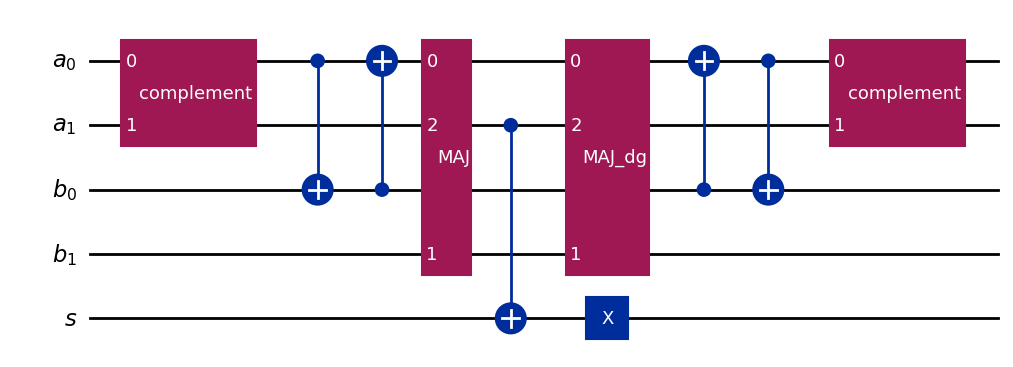

In [10]:
comparator_CDKM(2).draw("mpl")

In [14]:
from qiskit.quantum_info import Statevector
qc = QuantumCircuit(5)
#qc.x(0)
qc.x(1)
qc.x(2)
#qc.x(3)
qc.append(comparator_CDKM(2), range(5))
psi = Statevector(qc)
psi.draw("latex")

<IPython.core.display.Latex object>